In [48]:
import pandas as pd


In [49]:
df = pd.read_csv("reviews.csv")


# sørg for riktige typer
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["helpful"] = pd.to_numeric(df["helpful"], errors="coerce").fillna(0).astype(int)

# dato: du har både mm/dd og dd/mm i eksempelet, så vi prøver begge
d1 = pd.to_datetime(df["review_date"], errors="coerce", dayfirst=False)
d2 = pd.to_datetime(df["review_date"], errors="coerce", dayfirst=True)
df["review_date"] = d1.fillna(d2)

df.head()

df["sentiment"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)

/var/folders/g4/yk6n2qr95jz52s70_0mf4ydw0000gn/T/ipykernel_37860/4141399835.py:10: UserWarning: Parsing dates in %m/%d/%Y %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d2 = pd.to_datetime(df["review_date"], errors="coerce", dayfirst=True)


In [50]:
# logistic regression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Definer X og y
X = df["review_text"]
y = df["helpful"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Lag pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)),
    ("model", LogisticRegression())
])

# Tren modellen
pipeline.fit(X_train, y_train)

# Prediksjon
y_pred = pipeline.predict(X_test)

# Evaluer
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7971014492753623


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89       998
           1       0.17      0.01      0.02       185
           2       0.00      0.00      0.00        37
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         1
          36       0.00      0.00      0.00         1
          38       0.00      0.00      0.00         1
          48       0.00      0.00      0.00         1
          56       0.00    

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.6006441223832528
              precision    recall  f1-score   support

           1       0.55      0.69      0.61       321
           2       0.15      0.02      0.04        96
           3       0.10      0.03      0.05        99
           4       0.15      0.03      0.05       130
           5       0.67      0.87      0.76       596

    accuracy                           0.60      1242
   macro avg       0.32      0.33      0.30      1242
weighted avg       0.50      0.60      0.53      1242

[[220   2   7   6  86]
 [ 45   2  11   6  32]
 [ 37   3   3   7  49]
 [ 31   3   6   4  86]
 [ 68   3   4   4 517]]


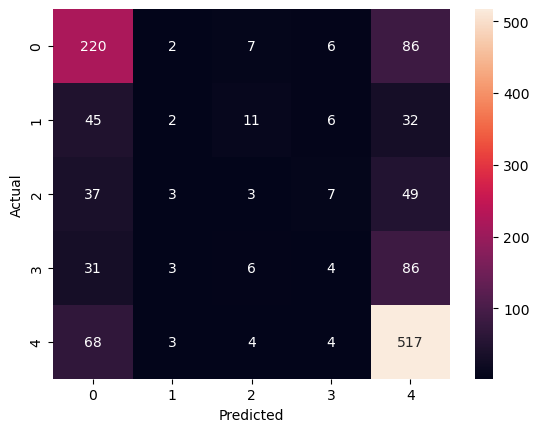

                                                 review  actual  predicted
6158                        I cannot register my number       3          1
1108                                           good app       5          5
4442  I want an option to set a profile pic for almo...       4          1
2480                                       love the app       5          5
167                                 I love the WhatsApp       5          5
1902                            status are blur nowdays       2          5
5176                    good but not downloading status       3          5
1235  objective objective objective objective object...       1          3
5806                             too many issues to say       1          5
3114  Cool enough, u can express ur feelings through...       5          5


In [52]:
# naive bayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["review_text"])

y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

results = pd.DataFrame({
    "review": df["review_text"].iloc[y_test.index],
    "actual": y_test,
    "predicted": y_pred
})

print(results.head(10))

In [53]:
# random forest?



In [54]:
# LSTM (neural network)